In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [11]:
# Task 0
X, y = make_blobs(
    n_samples=2000,
    n_features=2,
    centers=2,
    cluster_std=1.0,
    random_state=40
)
X.shape, np.bincount(y)

((2000, 2), array([1000, 1000]))

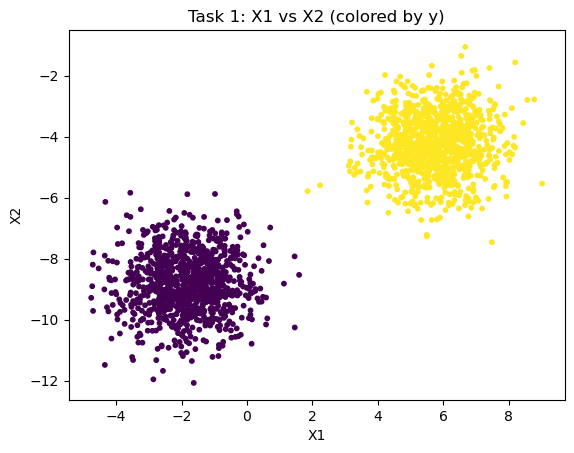

In [12]:
# Task 1
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Task 1: X1 vs X2 (colored by y)')
plt.show()

In [13]:
# Task 2
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=40,
    stratify=y
)
X_train.shape, X_test.shape

((1500, 2), (500, 2))

In [14]:
# Task 3
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

C_values = np.logspace(-3, 6, 10) 
param_grid = {'svc__C': C_values}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)
grid.best_params_, grid.best_score_

({'svc__C': np.float64(0.001)}, np.float64(1.0))

In [15]:
# Task 4
cv_results = pd.DataFrame(grid.cv_results_).sort_values('rank_test_score')
report_cols = [
    'rank_test_score',
    'param_svc__C',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'std_train_score'
]
cv_results[report_cols].reset_index(drop=True)

,rank_test_score,param_svc__C,mean_test_score,std_test_score,mean_train_score,std_train_score
0,1,0.001,1.0,0.0,1.0,0.0
1,1,0.010,1.0,0.0,1.0,0.0
2,1,0.100,1.0,0.0,1.0,0.0
3,1,1.000,1.0,0.0,1.0,0.0
4,1,10.000,1.0,0.0,1.0,0.0
5,1,100.000,1.0,0.0,1.0,0.0
6,1,1000.000,1.0,0.0,1.0,0.0
7,1,10000.000,1.0,0.0,1.0,0.0
8,1,100000.000,1.0,0.0,1.0,0.0
9,1,1000000.000,1.0,0.0,1.0,0.0


In [16]:
# Task 5
best_C = grid.best_params_['svc__C']
print("Selected model: Pipeline(StandardScaler + SVC(kernel='linear'))")
print('Best C:', best_C)
print('Best CV accuracy:', grid.best_score_)

Selected model: Pipeline(StandardScaler + SVC(kernel='linear'))
Best C: 0.001
Best CV accuracy: 1.0


In [17]:
# Task 6
y_pred = grid.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print('Test accuracy:', test_acc)

Test accuracy: 1.0


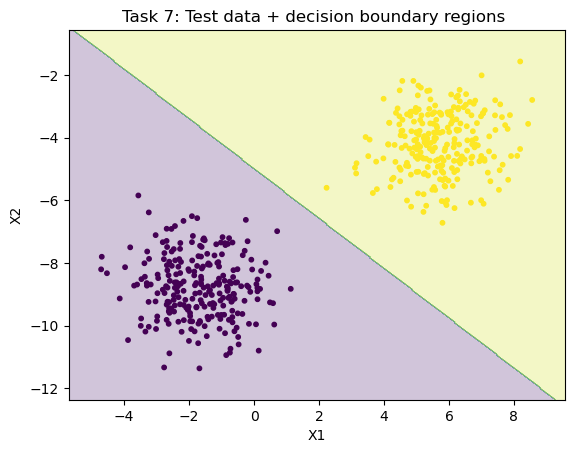

In [18]:
# Task 7
best_model = grid.best_estimator_

x_min, x_max = X_test[:, 0].min() - 1.0, X_test[:, 0].max() + 1.0
y_min, y_max = X_test[:, 1].min() - 1.0, X_test[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=10)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Task 7: Test data + decision boundary regions ')
plt.show()